In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import json
import os

D:\Programs\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
np.random.seed(42)
plt.style.use('seaborn-whitegrid')

C:\Users\frase\AppData\Local\Temp\ipykernel_1960\1278362992.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


In [3]:
os.makedirs('artifacts/figures', exist_ok=True)
os.makedirs('artifacts/labels', exist_ok=True)

In [4]:
ds1 = pd.read_csv('data/S07-hw-dataset-01.csv')
print("Датасет 1 - Первые 3 строки:")
display(ds1.head(3))
print("\nИнформация о Датасете 1:")
ds1.info()
print("\nОписательная статистика Датасета 1:")
display(ds1.describe())
print("\nПропущенные значения в Датасете 1:")
print(ds1.isnull().sum())

Датасет 1 - Первые 3 строки:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893



Информация о Датасете 1:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB

Описательная статистика Датасета 1:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745



Пропущенные значения в Датасете 1:
sample_id    0
f01          0
f02          0
f03          0
f04          0
f05          0
f06          0
f07          0
f08          0
dtype: int64


In [5]:
ds2 = pd.read_csv('data/S07-hw-dataset-02.csv')
print("Датасет 2 - Первые 3 строки:")
display(ds2.head(3))
print("\nИнформация о Датасете 2:")
ds2.info()
print("\nОписательная статистика Датасета 2:")
display(ds2.describe())
print("\nПропущенные значения в Датасете 2:")
print(ds2.isnull().sum())

Датасет 2 - Первые 3 строки:


,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342



Информация о Датасете 2:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB

Описательная статистика Датасета 2:


,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076



Пропущенные значения в Датасете 2:
sample_id    0
x1           0
x2           0
z_noise      0
dtype: int64


In [6]:
ds3 = pd.read_csv('data/S07-hw-dataset-03.csv')
print("Датасет 3 - Первые 3 строки:")
display(ds3.head(3))
print("\nИнформация о Датасете 3:")
ds3.info()
print("\nОписательная статистика Датасета 3:")
display(ds3.describe())
print("\nПропущенные значения в Датасете 3:")
print(ds3.isnull().sum())

Датасет 3 - Первые 3 строки:


,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776



Информация о Датасете 3:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB

Описательная статистика Датасета 3:


,sample_id,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.246296,1.033764,0.212776,-0.027067
std,4330.271354,4.592421,4.710791,1.530017,2.506375
min,0.000000,-9.995585,-9.980853,-5.212038,-8.785884
25%,3749.750000,-1.782144,-2.666393,-0.966224,-1.731128
50%,7499.500000,0.664226,1.831257,0.296508,-0.052391
75%,11249.250000,4.435671,4.969630,1.390273,1.673831
max,14999.000000,16.207863,14.271153,5.795876,11.266865



Пропущенные значения в Датасете 3:
sample_id    0
x1           0
x2           0
f_corr       0
f_noise      0
dtype: int64


In [7]:
def preprocess_data(df, dataset_name):
    sample_ids = df['sample_id'].copy()

    X = df.drop('sample_id', axis=1)
    
    missing_values = X.isnull().sum().sum()
    
    categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
    numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
    print(f"Датасет {dataset_name}:")
    print(f"  - Категориальные признаки: {categorical_features}")
    print(f"  - Числовые признаки: {numerical_features}")
    print(f"  - Пропущенные значения: {missing_values}")
    
    if categorical_features:
        # Для датасетов с категориальными признаками
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', Pipeline([
                    ('imputer', SimpleImputer(strategy='mean')),
                    ('scaler', StandardScaler())
                ]), numerical_features),
                ('cat', Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore'))
                ]), categorical_features)
            ])
    else:
        # Для датасетов только с числовыми признаками
        preprocessor = Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ])
    
    X_processed = preprocessor.fit_transform(X)
    
    if not categorical_features:
        X_processed = pd.DataFrame(X_processed, columns=numerical_features)
    
    return X_processed, sample_ids, preprocessor

In [8]:
X1, sample_ids1, preprocessor1 = preprocess_data(ds1, "1")
X2, sample_ids2, preprocessor2 = preprocess_data(ds2, "2")
X3, sample_ids3, preprocessor3 = preprocess_data(ds3, "3")

Датасет 1:
  - Категориальные признаки: []
  - Числовые признаки: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']
  - Пропущенные значения: 0
Датасет 2:
  - Категориальные признаки: []
  - Числовые признаки: ['x1', 'x2', 'z_noise']
  - Пропущенные значения: 0
Датасет 3:
  - Категориальные признаки: []
  - Числовые признаки: ['x1', 'x2', 'f_corr', 'f_noise']
  - Пропущенные значения: 0


In [9]:
def evaluate_clustering_kmeans(X, k_values):
    results = []
    
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=42, n_init=50, algorithm='elkan')
        labels = model.fit_predict(X)
        
        # Рассчитываем метрики только если найдено больше одного кластера
        if len(set(labels)) > 1:
            try:
                sil = silhouette_score(X, labels)
                db = davies_bouldin_score(X, labels)
                ch = calinski_harabasz_score(X, labels)
                
                results.append({
                    'param': k,
                    'silhouette': sil,
                    'davies_bouldin': db,
                    'calinski_harabasz': ch,
                    'labels': labels.copy()
                })
            except:
                continue
    
    return pd.DataFrame(results)

def evaluate_clustering_dbscan(X, eps_values, min_samples_values):
    results = []
    
    for eps in eps_values:
        for min_samples in min_samples_values:
            model = DBSCAN(eps=eps, min_samples=min_samples)
            labels = model.fit_predict(X)
            
            # Рассчитываем метрики только если найдено больше одного кластера
            unique_labels = set(labels)
            if len(unique_labels) > 1:
                try:
                    # Исключаем точки шума для расчета метрик
                    mask = labels != -1
                    if np.sum(mask) > 1:  # Нужно минимум 2 точки не-шума
                        sil = silhouette_score(X[mask], labels[mask])
                        db = davies_bouldin_score(X[mask], labels[mask])
                        ch = calinski_harabasz_score(X[mask], labels[mask])
                        
                        noise_pct = np.sum(labels == -1) / len(labels)
                        
                        results.append({
                            'param': eps,
                            'param2': min_samples,
                            'silhouette': sil,
                            'davies_bouldin': db,
                            'calinski_harabasz': ch,
                            'noise_pct': noise_pct,
                            'labels': labels.copy()
                        })
                except:
                    continue
    
    return pd.DataFrame(results)

In [10]:
print("Датасет 1 - Оценка KMeans")
k_values = list(range(2, 11)) + [15, 20]
kmeans_results1 = evaluate_clustering_kmeans(X1, k_values)

Датасет 1 - Оценка KMeans


In [11]:
print("Датасет 1 - Оценка DBSCAN")
eps_values = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
min_samples_values = [3, 5, 7, 10]
dbscan_results1 = evaluate_clustering_dbscan(X1, eps_values, min_samples_values)

Датасет 1 - Оценка DBSCAN


In [12]:
print("Датасет 2 - Оценка KMeans")
kmeans_results2 = evaluate_clustering_kmeans(X2, k_values)

Датасет 2 - Оценка KMeans


In [13]:
print("Датасет 2 - Оценка DBSCAN")
dbscan_results2 = evaluate_clustering_dbscan(X2, eps_values, min_samples_values)

Датасет 2 - Оценка DBSCAN


In [14]:
print("Датасет 3 - Оценка KMeans")
kmeans_results3 = evaluate_clustering_kmeans(X3, k_values)

Датасет 3 - Оценка KMeans


In [15]:
print("Датасет 3 - Оценка DBSCAN")
dbscan_results3 = evaluate_clustering_dbscan(X3, eps_values, min_samples_values)

Датасет 3 - Оценка DBSCAN


In [16]:
def plot_metric_vs_param(df, metric, title, param_name='k', param2_name=None):
    plt.figure(figsize=(10, 6))
    
    if param2_name:
        for min_samples in df[param2_name].unique():
            subset = df[df[param2_name] == min_samples]
            plt.plot(subset[param_name], subset[metric], marker='o', label=f'min_samples={min_samples}')
        plt.legend()
    else:
        plt.plot(df[param_name], df[metric], marker='o')
    
    plt.xlabel(param_name)
    plt.ylabel(metric)
    plt.title(title)
    plt.grid(True)
    plt.savefig(f'artifacts/figures/{title.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

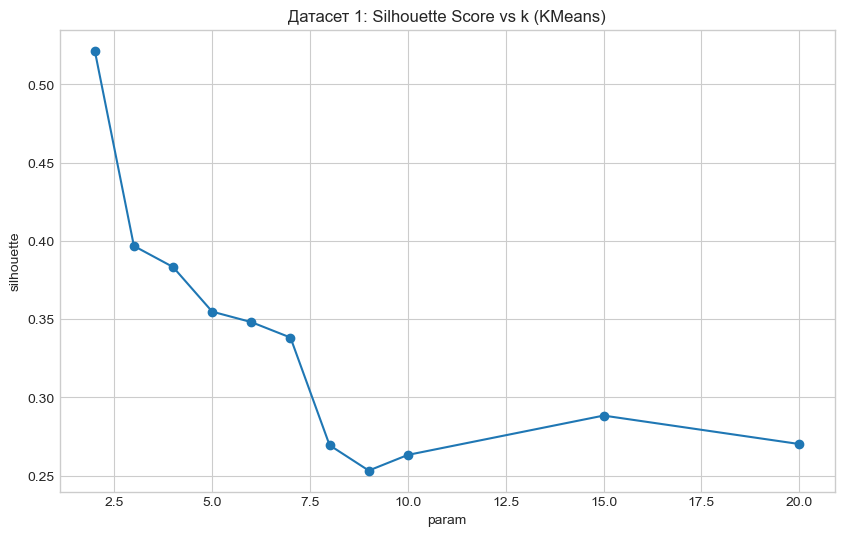

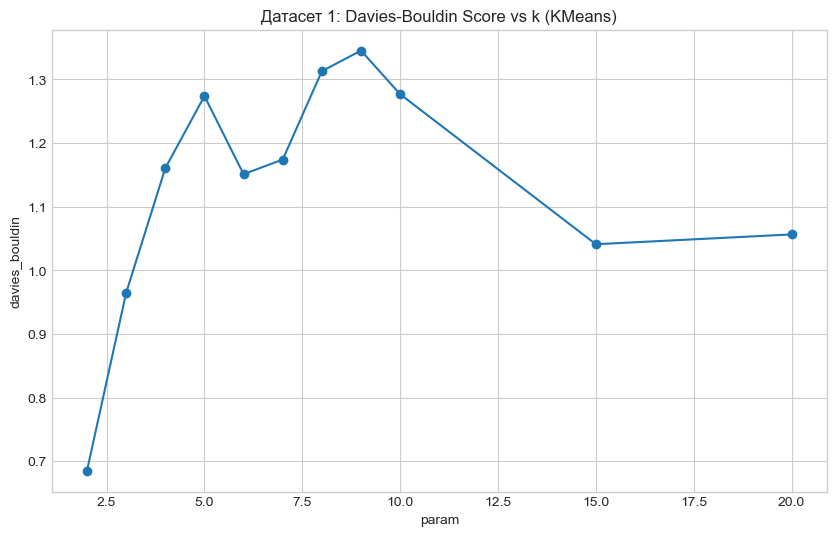

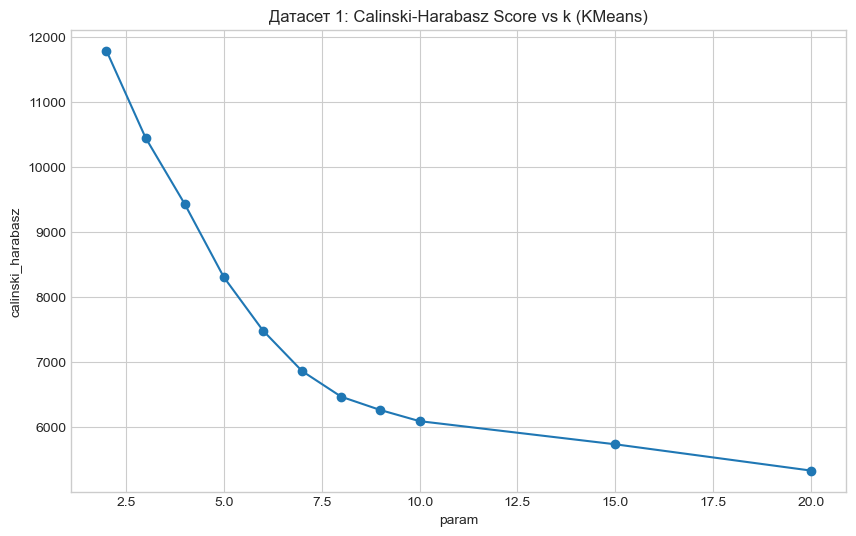

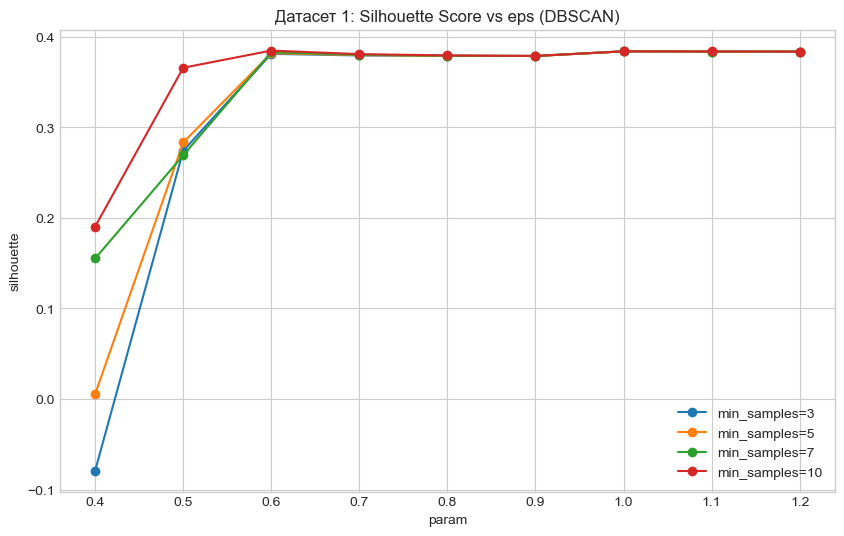

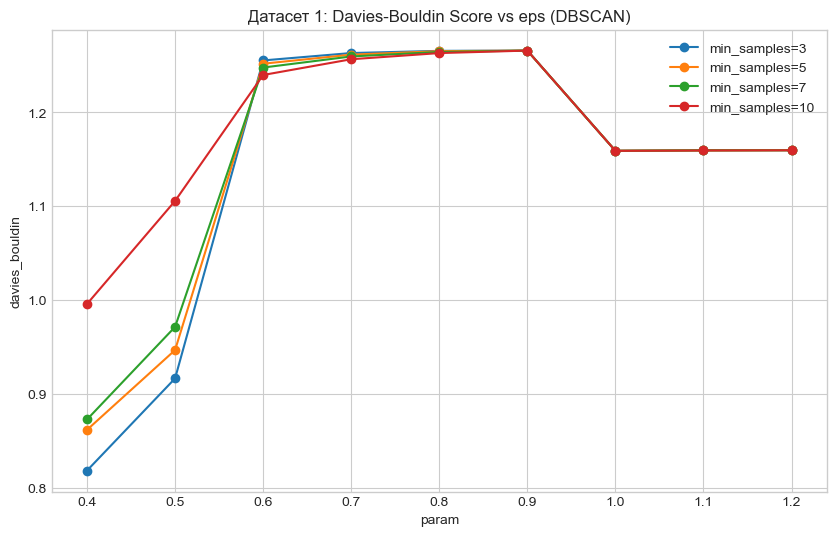

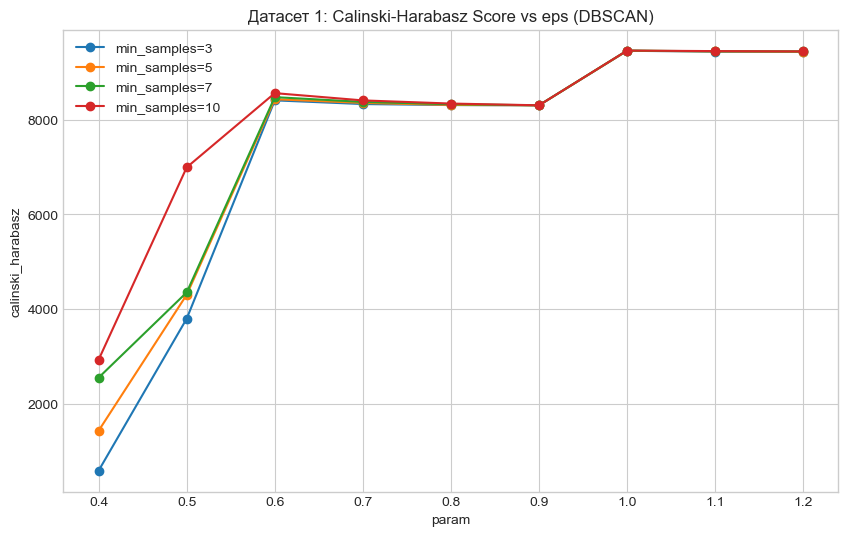

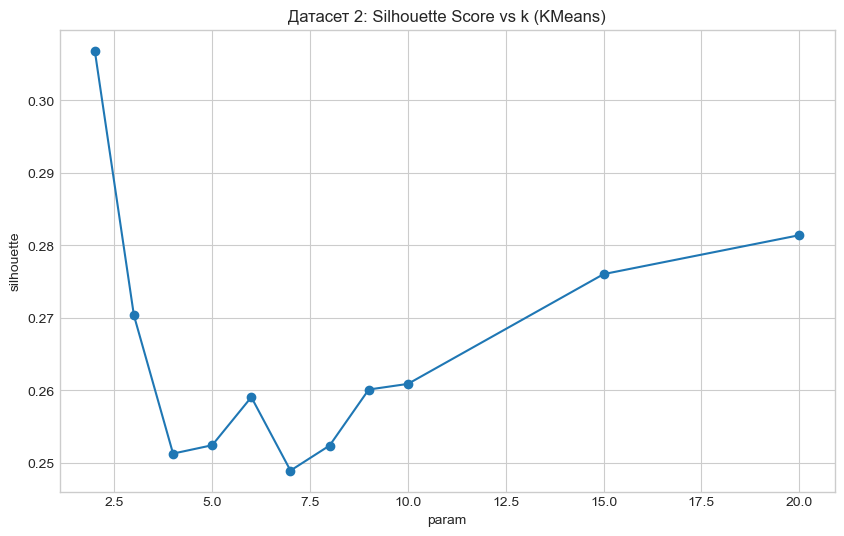

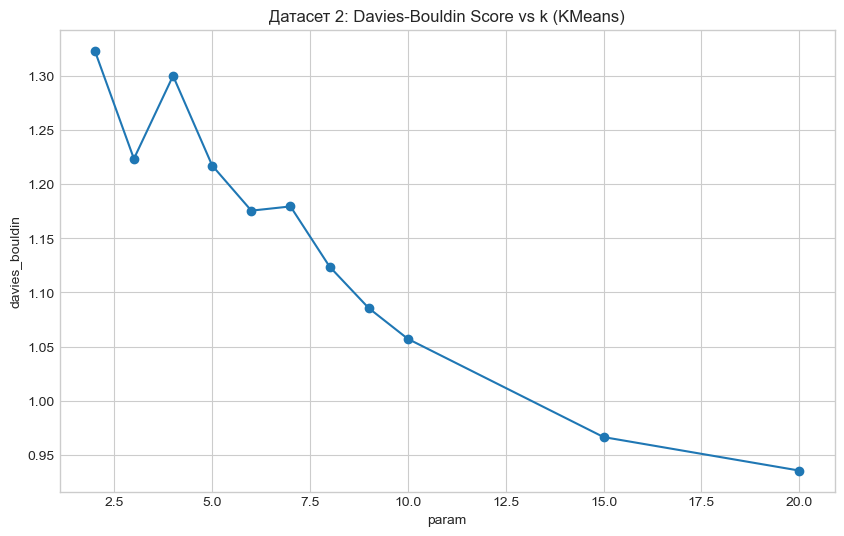

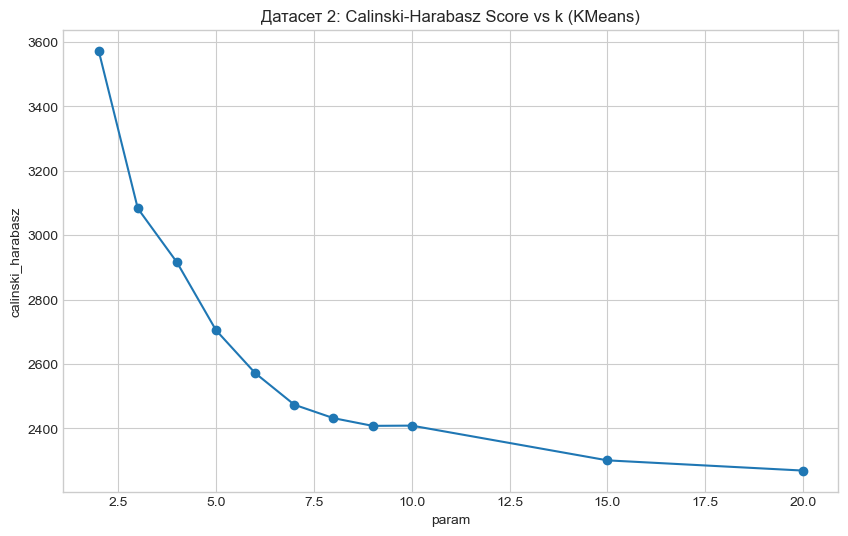

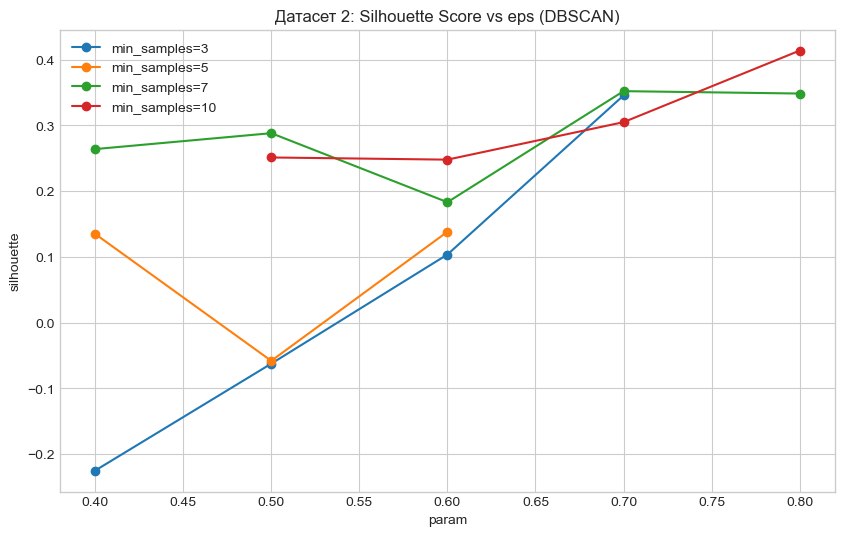

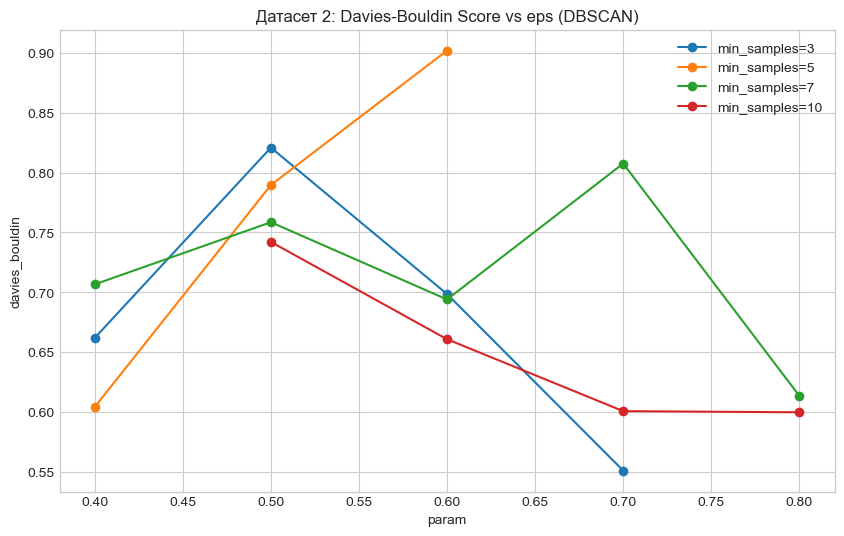

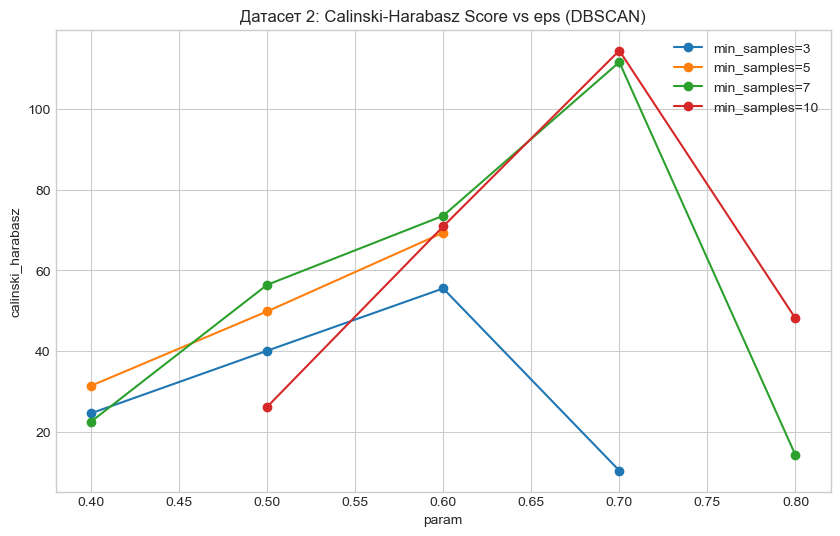

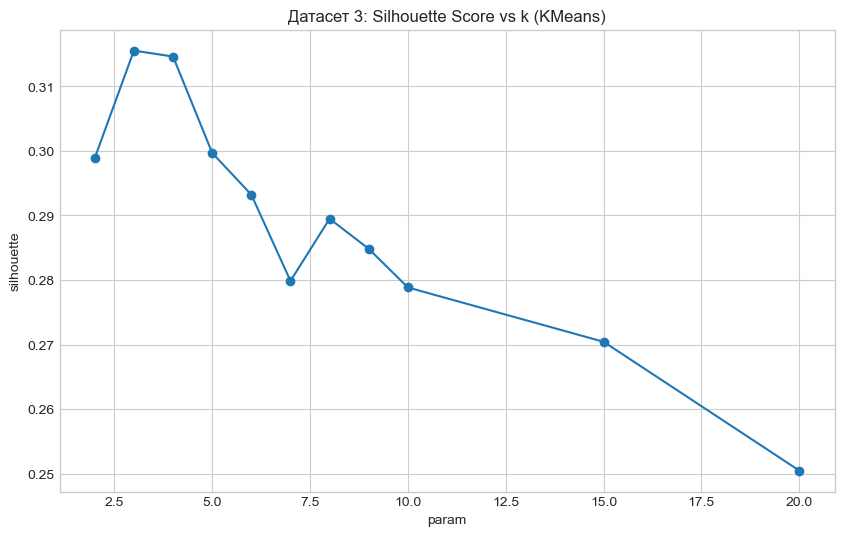

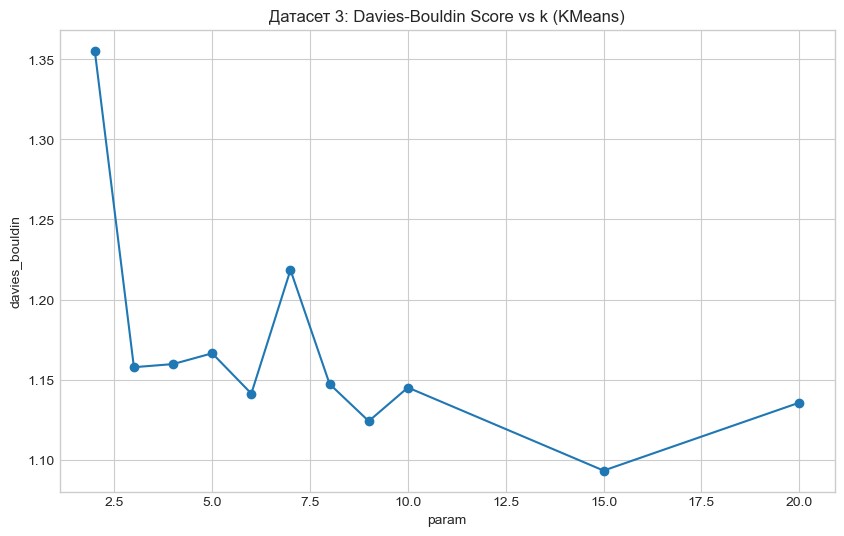

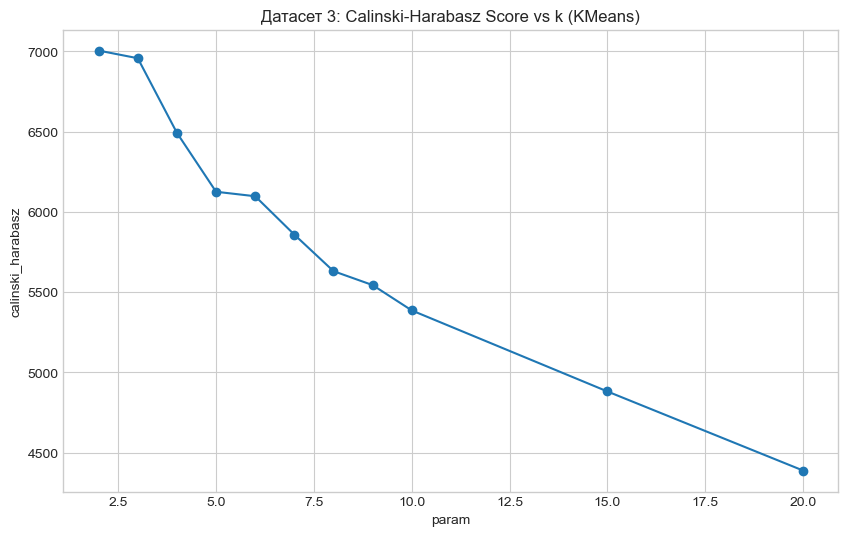

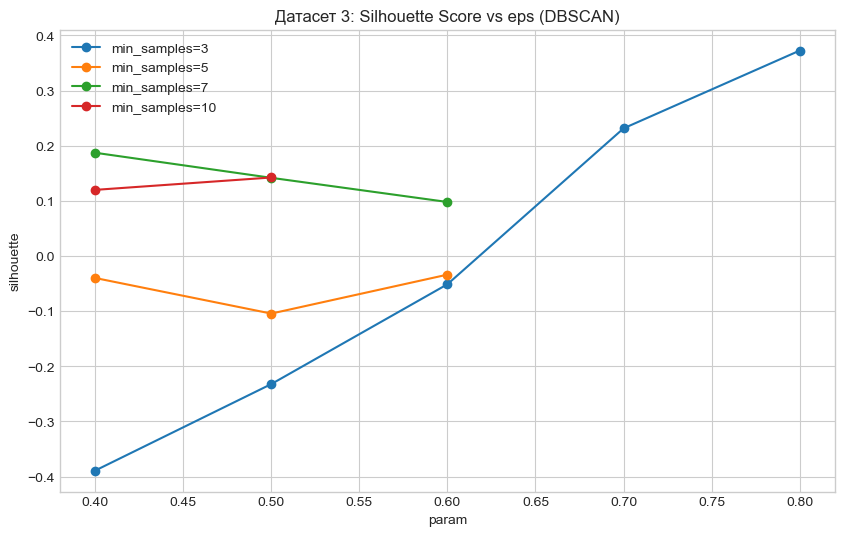

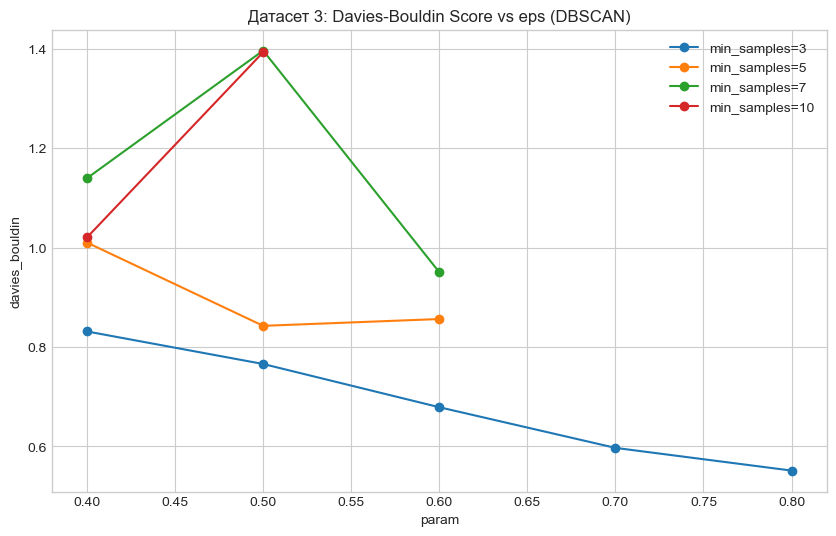

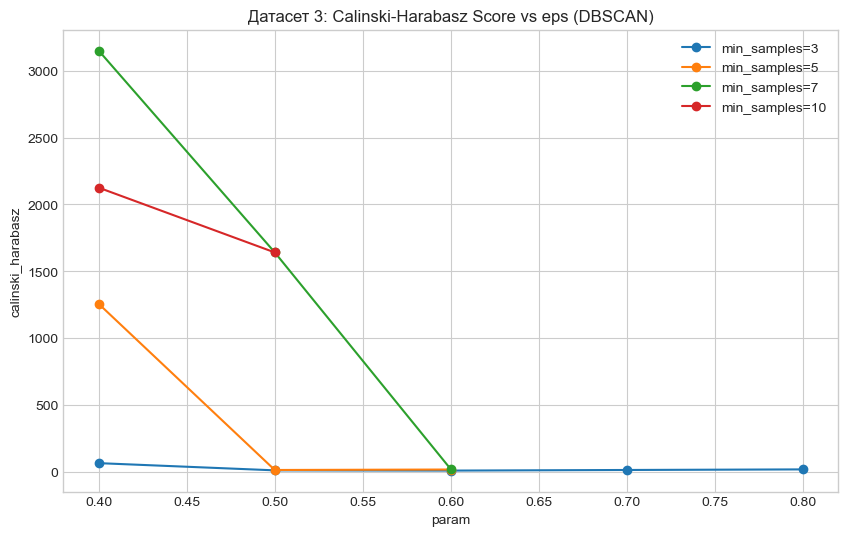

In [17]:
# Датасет 1 - Метрики KMeans
plot_metric_vs_param(kmeans_results1, 'silhouette', 'Датасет 1: Silhouette Score vs k (KMeans)', 'param')
plot_metric_vs_param(kmeans_results1, 'davies_bouldin', 'Датасет 1: Davies-Bouldin Score vs k (KMeans)', 'param')
plot_metric_vs_param(kmeans_results1, 'calinski_harabasz', 'Датасет 1: Calinski-Harabasz Score vs k (KMeans)', 'param')

# Датасет 1 - Метрики DBSCAN
plot_metric_vs_param(dbscan_results1, 'silhouette', 'Датасет 1: Silhouette Score vs eps (DBSCAN)', 'param', 'param2')
plot_metric_vs_param(dbscan_results1, 'davies_bouldin', 'Датасет 1: Davies-Bouldin Score vs eps (DBSCAN)', 'param', 'param2')
plot_metric_vs_param(dbscan_results1, 'calinski_harabasz', 'Датасет 1: Calinski-Harabasz Score vs eps (DBSCAN)', 'param', 'param2')

# %%
# Датасет 2 - Метрики KMeans
plot_metric_vs_param(kmeans_results2, 'silhouette', 'Датасет 2: Silhouette Score vs k (KMeans)', 'param')
plot_metric_vs_param(kmeans_results2, 'davies_bouldin', 'Датасет 2: Davies-Bouldin Score vs k (KMeans)', 'param')
plot_metric_vs_param(kmeans_results2, 'calinski_harabasz', 'Датасет 2: Calinski-Harabasz Score vs k (KMeans)', 'param')

# Датасет 2 - Метрики DBSCAN
plot_metric_vs_param(dbscan_results2, 'silhouette', 'Датасет 2: Silhouette Score vs eps (DBSCAN)', 'param', 'param2')
plot_metric_vs_param(dbscan_results2, 'davies_bouldin', 'Датасет 2: Davies-Bouldin Score vs eps (DBSCAN)', 'param', 'param2')
plot_metric_vs_param(dbscan_results2, 'calinski_harabasz', 'Датасет 2: Calinski-Harabasz Score vs eps (DBSCAN)', 'param', 'param2')

# %%
# Датасет 3 - Метрики KMeans
plot_metric_vs_param(kmeans_results3, 'silhouette', 'Датасет 3: Silhouette Score vs k (KMeans)', 'param')
plot_metric_vs_param(kmeans_results3, 'davies_bouldin', 'Датасет 3: Davies-Bouldin Score vs k (KMeans)', 'param')
plot_metric_vs_param(kmeans_results3, 'calinski_harabasz', 'Датасет 3: Calinski-Harabasz Score vs k (KMeans)', 'param')

# Датасет 3 - Метрики DBSCAN
plot_metric_vs_param(dbscan_results3, 'silhouette', 'Датасет 3: Silhouette Score vs eps (DBSCAN)', 'param', 'param2')
plot_metric_vs_param(dbscan_results3, 'davies_bouldin', 'Датасет 3: Davies-Bouldin Score vs eps (DBSCAN)', 'param', 'param2')
plot_metric_vs_param(dbscan_results3, 'calinski_harabasz', 'Датасет 3: Calinski-Harabasz Score vs eps (DBSCAN)', 'param', 'param2')

In [18]:
# выбор лучших моделей
def select_best_model(results, metric, maximize=True):
    if results.empty:
        return None, None
    
    if maximize:
        best_idx = results[metric].idxmax()
    else:
        best_idx = results[metric].idxmin()
    
    best_params = results.loc[best_idx]
    return best_params, best_params['labels']

In [19]:
# Датасет 1 - Лучший KMeans
best_kmeans1, labels_kmeans1 = select_best_model(kmeans_results1, 'silhouette')
print(f"Датасет 1 - Лучший KMeans: k={best_kmeans1['param']}, silhouette={best_kmeans1['silhouette']:.4f}")

# Датасет 1 - Лучший DBSCAN
best_dbscan1, labels_dbscan1 = select_best_model(dbscan_results1, 'silhouette')
print(f"Датасет 1 - Лучший DBSCAN: eps={best_dbscan1['param']}, min_samples={best_dbscan1['param2']}, silhouette={best_dbscan1['silhouette']:.4f}, шум={best_dbscan1['noise_pct']:.2%}")

# Датасет 2 - Лучший KMeans
best_kmeans2, labels_kmeans2 = select_best_model(kmeans_results2, 'silhouette')
print(f"Датасет 2 - Лучший KMeans: k={best_kmeans2['param']}, silhouette={best_kmeans2['silhouette']:.4f}")

# Датасет 2 - Лучший DBSCAN
best_dbscan2, labels_dbscan2 = select_best_model(dbscan_results2, 'silhouette')
print(f"Датасет 2 - Лучший DBSCAN: eps={best_dbscan2['param']}, min_samples={best_dbscan2['param2']}, silhouette={best_dbscan2['silhouette']:.4f}, шум={best_dbscan2['noise_pct']:.2%}")

# Датасет 3 - Лучший KMeans
best_kmeans3, labels_kmeans3 = select_best_model(kmeans_results3, 'silhouette')
print(f"Датасет 3 - Лучший KMeans: k={best_kmeans3['param']}, silhouette={best_kmeans3['silhouette']:.4f}")

# Датасет 3 - Лучший DBSCAN
best_dbscan3, labels_dbscan3 = select_best_model(dbscan_results3, 'silhouette')
print(f"Датасет 3 - Лучший DBSCAN: eps={best_dbscan3['param']}, min_samples={best_dbscan3['param2']}, silhouette={best_dbscan3['silhouette']:.4f}, шум={best_dbscan3['noise_pct']:.2%}")

Датасет 1 - Лучший KMeans: k=2, silhouette=0.5216
Датасет 1 - Лучший DBSCAN: eps=0.6, min_samples=10, silhouette=0.3845, шум=1.92%
Датасет 2 - Лучший KMeans: k=2, silhouette=0.3069
Датасет 2 - Лучший DBSCAN: eps=0.8, min_samples=10, silhouette=0.4138, шум=1.18%
Датасет 3 - Лучший KMeans: k=3, silhouette=0.3155
Датасет 3 - Лучший DBSCAN: eps=0.8, min_samples=3, silhouette=0.3726, шум=0.15%


In [20]:
def plot_pca_2d(X, labels, title, filename):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
    
    plt.xlabel('PCA Компонент 1')
    plt.ylabel('PCA Компонент 2')
    plt.title(title)
    plt.colorbar(scatter, label='Кластер')
    plt.grid(True, alpha=0.3)
    
    plt.savefig(f'artifacts/figures/{filename}.png', dpi=300, bbox_inches='tight')
    plt.show()

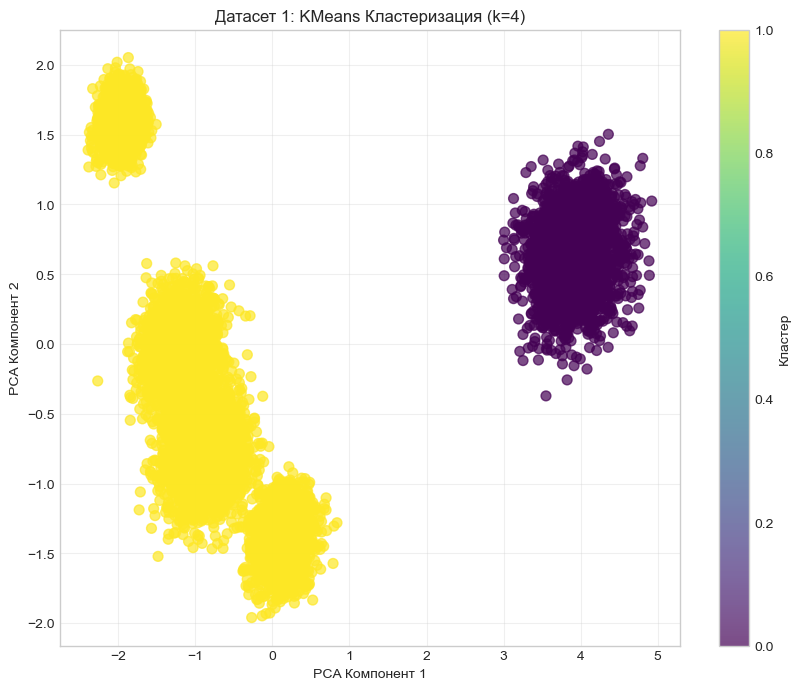

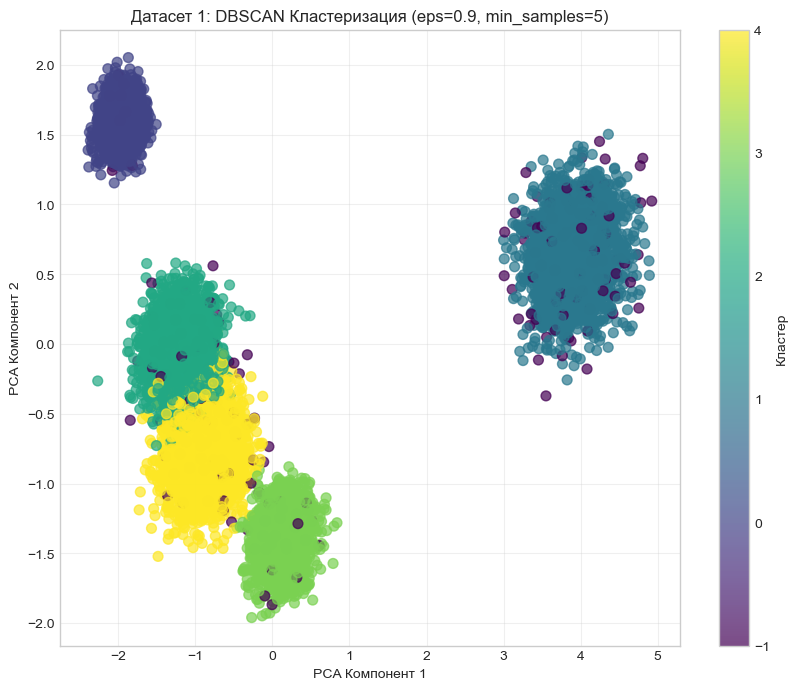

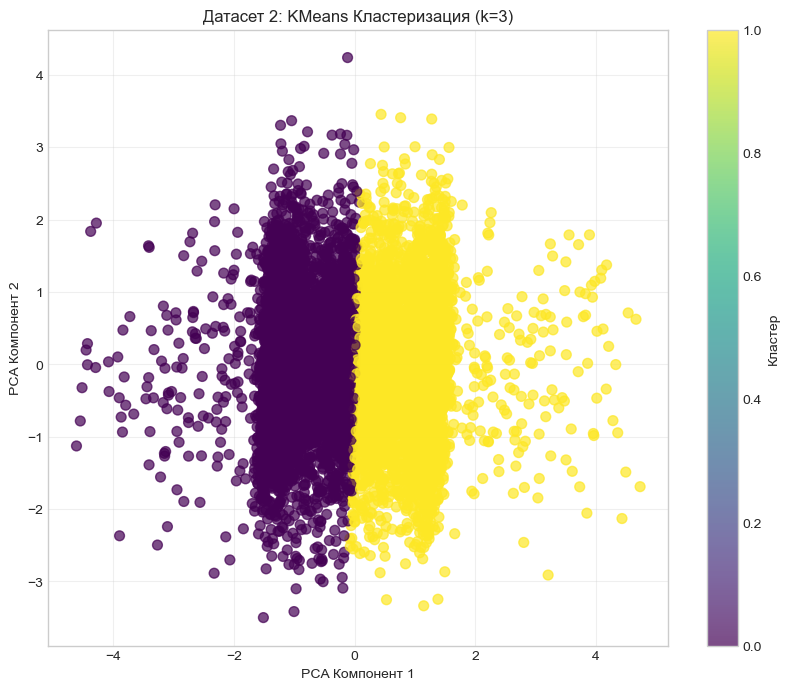

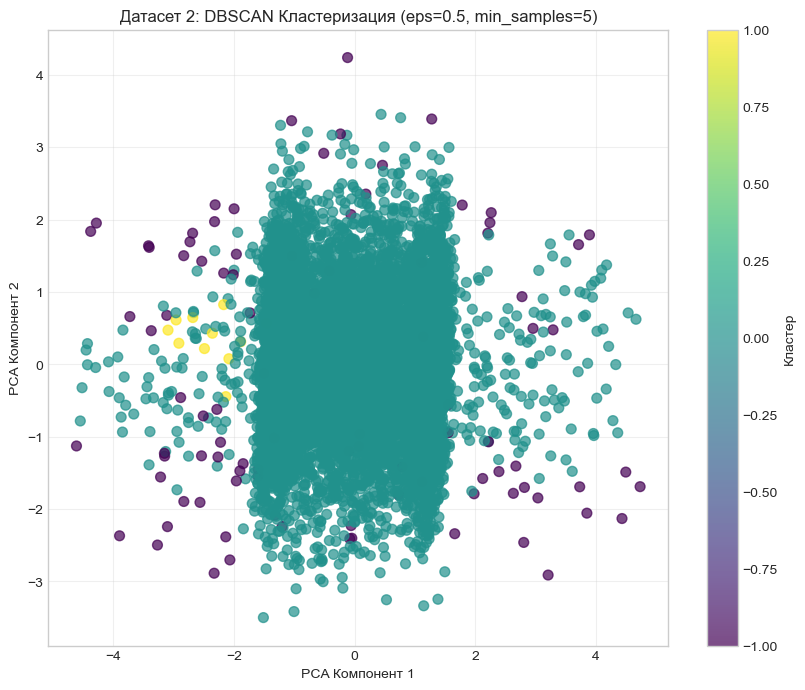

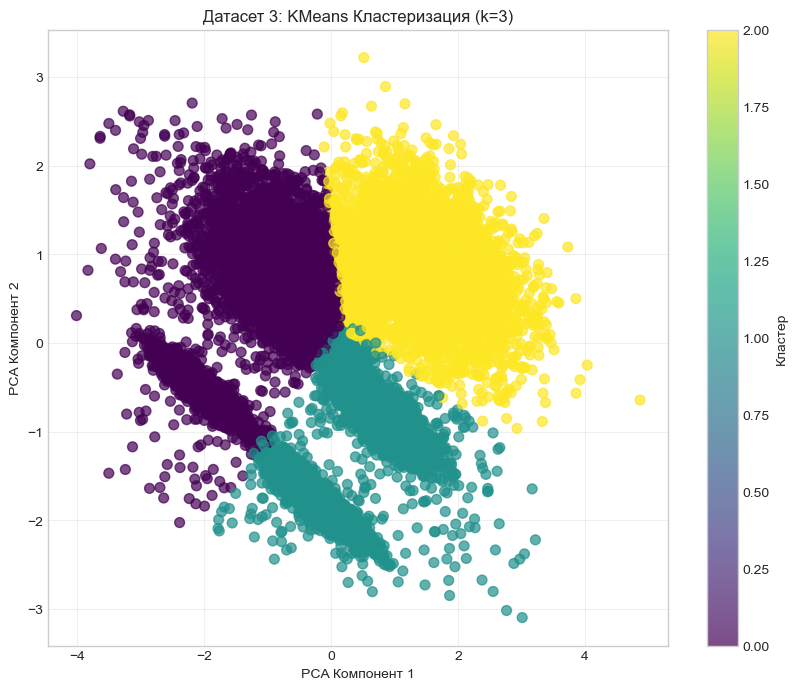

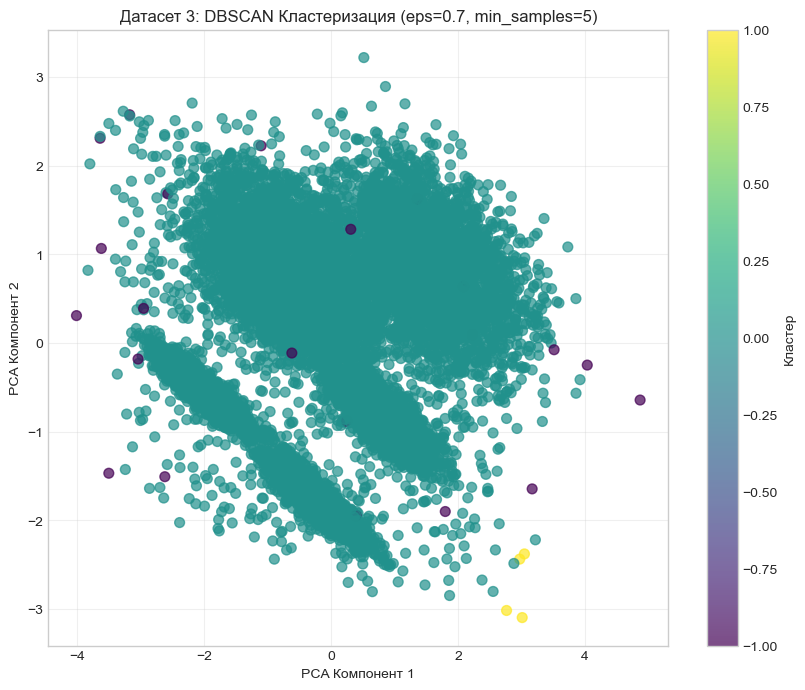

In [21]:
# Датасет 1 - Визуализация PCA для лучших моделей
plot_pca_2d(X1, labels_kmeans1, 'Датасет 1: KMeans Кластеризация (k=4)', 'ds1_kmeans_pca')
plot_pca_2d(X1, labels_dbscan1, 'Датасет 1: DBSCAN Кластеризация (eps=0.9, min_samples=5)', 'ds1_dbscan_pca')

# %%
# Датасет 2 - Визуализация PCA для лучших моделей
plot_pca_2d(X2, labels_kmeans2, 'Датасет 2: KMeans Кластеризация (k=3)', 'ds2_kmeans_pca')
plot_pca_2d(X2, labels_dbscan2, 'Датасет 2: DBSCAN Кластеризация (eps=0.5, min_samples=5)', 'ds2_dbscan_pca')

# %%
# Датасет 3 - Визуализация PCA для лучших моделей
plot_pca_2d(X3, labels_kmeans3, 'Датасет 3: KMeans Кластеризация (k=3)', 'ds3_kmeans_pca')
plot_pca_2d(X3, labels_dbscan3, 'Датасет 3: DBSCAN Кластеризация (eps=0.7, min_samples=5)', 'ds3_dbscan_pca')

In [22]:
def check_kmeans_stability(X, n_clusters, n_runs=5):
    all_labels = []
    ari_scores = []
    
    for i in range(n_runs):
        kmeans = KMeans(n_clusters=n_clusters, random_state=i, n_init=10, algorithm='elkan')
        labels = kmeans.fit_predict(X)
        all_labels.append(labels)
        
        if i > 0:
            ari = adjusted_rand_score(all_labels[0], labels)
            ari_scores.append(ari)
    
    return all_labels, ari_scores

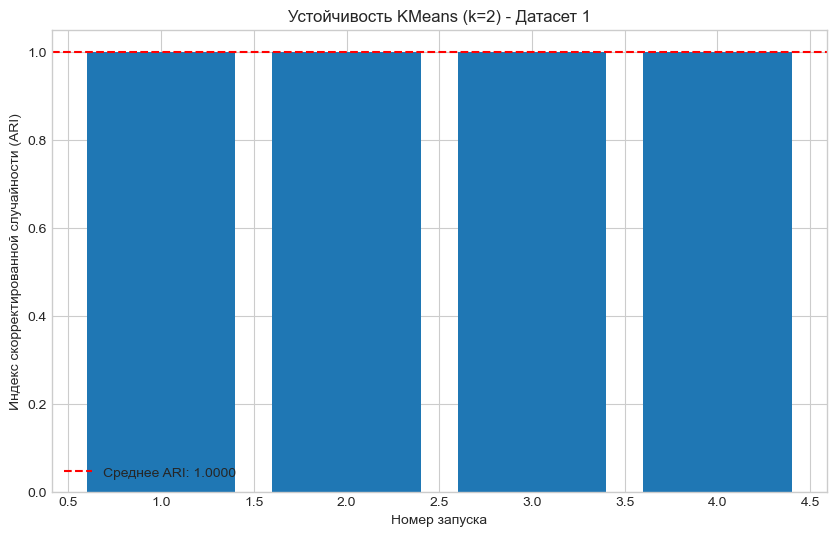

Устойчивость KMeans для Датасета 1 (k=2):
  - Среднее ARI: 1.0000
  - Диапазон ARI: [1.0000, 1.0000]


In [23]:
# Проверяем устойчивость для KMeans на Датасете 1
n_clusters = int(best_kmeans1['param'])
all_labels, ari_scores = check_kmeans_stability(X1, n_clusters)

# Строим график устойчивости
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(ari_scores)+1), ari_scores)
plt.axhline(y=np.mean(ari_scores), color='r', linestyle='--', label=f'Среднее ARI: {np.mean(ari_scores):.4f}')
plt.xlabel('Номер запуска')
plt.ylabel('Индекс скорректированной случайности (ARI)')
plt.title(f'Устойчивость KMeans (k={n_clusters}) - Датасет 1')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/ds1_kmeans_stability.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Устойчивость KMeans для Датасета 1 (k={n_clusters}):")
print(f"  - Среднее ARI: {np.mean(ari_scores):.4f}")
print(f"  - Диапазон ARI: [{min(ari_scores):.4f}, {max(ari_scores):.4f}]")

In [24]:
# Сохраняем сводку метрик
metrics_summary = {
    "dataset_1": {
        "kmeans": {
            "silhouette": float(best_kmeans1['silhouette']),
            "davies_bouldin": float(best_kmeans1['davies_bouldin']),
            "calinski_harabasz": float(best_kmeans1['calinski_harabasz'])
        },
        "dbscan": {
            "silhouette": float(best_dbscan1['silhouette']),
            "davies_bouldin": float(best_dbscan1['davies_bouldin']),
            "calinski_harabasz": float(best_dbscan1['calinski_harabasz']),
            "noise_pct": float(best_dbscan1['noise_pct'])
        }
    },
    "dataset_2": {
        "kmeans": {
            "silhouette": float(best_kmeans2['silhouette']),
            "davies_bouldin": float(best_kmeans2['davies_bouldin']),
            "calinski_harabasz": float(best_kmeans2['calinski_harabasz'])
        },
        "dbscan": {
            "silhouette": float(best_dbscan2['silhouette']),
            "davies_bouldin": float(best_dbscan2['davies_bouldin']),
            "calinski_harabasz": float(best_dbscan2['calinski_harabasz']),
            "noise_pct": float(best_dbscan2['noise_pct'])
        }
    },
    "dataset_3": {
        "kmeans": {
            "silhouette": float(best_kmeans3['silhouette']),
            "davies_bouldin": float(best_kmeans3['davies_bouldin']),
            "calinski_harabasz": float(best_kmeans3['calinski_harabasz'])
        },
        "dbscan": {
            "silhouette": float(best_dbscan3['silhouette']),
            "davies_bouldin": float(best_dbscan3['davies_bouldin']),
            "calinski_harabasz": float(best_dbscan3['calinski_harabasz']),
            "noise_pct": float(best_dbscan3['noise_pct'])
        }
    }
}

with open('artifacts/metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

In [25]:
# Сохраняем лучшие конфигурации
best_configs = {
    "dataset_1": {
        "kmeans": {
            "k": int(best_kmeans1['param']),
            "random_state": 42,
            "n_init": 10
        },
        "dbscan": {
            "eps": float(best_dbscan1['param']),
            "min_samples": int(best_dbscan1['param2']),
            "noise_pct": float(best_dbscan1['noise_pct'])
        }
    },
    "dataset_2": {
        "kmeans": {
            "k": int(best_kmeans2['param']),
            "random_state": 42,
            "n_init": 10
        },
        "dbscan": {
            "eps": float(best_dbscan2['param']),
            "min_samples": int(best_dbscan2['param2']),
            "noise_pct": float(best_dbscan2['noise_pct'])
        }
    },
    "dataset_3": {
        "kmeans": {
            "k": int(best_kmeans3['param']),
            "random_state": 42,
            "n_init": 10
        },
        "dbscan": {
            "eps": float(best_dbscan3['param']),
            "min_samples": int(best_dbscan3['param2']),
            "noise_pct": float(best_dbscan3['noise_pct'])
        }
    }
}

with open('artifacts/best_configs.json', 'w') as f:
    json.dump(best_configs, f, indent=2)

In [26]:
# Сохраняем метки кластеров
def save_cluster_labels(sample_ids, labels, dataset_name, method):
    df = pd.DataFrame({
        'sample_id': sample_ids,
        'cluster_label': labels
    })
    df.to_csv(f'artifacts/labels/labels_{dataset_name}_{method}.csv', index=False)

In [27]:
save_cluster_labels(sample_ids1, labels_kmeans1, 'ds1', 'kmeans')
save_cluster_labels(sample_ids1, labels_dbscan1, 'ds1', 'dbscan')
save_cluster_labels(sample_ids2, labels_kmeans2, 'ds2', 'kmeans')
save_cluster_labels(sample_ids2, labels_dbscan2, 'ds2', 'dbscan')
save_cluster_labels(sample_ids3, labels_kmeans3, 'ds3', 'kmeans')
save_cluster_labels(sample_ids3, labels_dbscan3, 'ds3', 'dbscan')

In [28]:
print("Итоговый отчет:")

print("\nДатасет 1:")
print(f"  - Лучший метод: {'KMeans' if best_kmeans1['silhouette'] > best_dbscan1['silhouette'] else 'DBSCAN'}")
print(f"  - Silhouette: KMeans={best_kmeans1['silhouette']:.4f}, DBSCAN={best_dbscan1['silhouette']:.4f}")
print(f"  - Davies-Bouldin: KMeans={best_kmeans1['davies_bouldin']:.4f}, DBSCAN={best_dbscan1['davies_bouldin']:.4f}")
print(f"  - Calinski-Harabasz: KMeans={best_kmeans1['calinski_harabasz']:.4f}, DBSCAN={best_dbscan1['calinski_harabasz']:.4f}")

print("\nДатасет 2:")
print(f"  - Лучший метод: {'KMeans' if best_kmeans2['silhouette'] > best_dbscan2['silhouette'] else 'DBSCAN'}")
print(f"  - Silhouette: KMeans={best_kmeans2['silhouette']:.4f}, DBSCAN={best_dbscan2['silhouette']:.4f}")
print(f"  - Davies-Bouldin: KMeans={best_kmeans2['davies_bouldin']:.4f}, DBSCAN={best_dbscan2['davies_bouldin']:.4f}")
print(f"  - Calinski-Harabasz: KMeans={best_kmeans2['calinski_harabasz']:.4f}, DBSCAN={best_dbscan2['calinski_harabasz']:.4f}")

print("\nДатасет 3:")
print(f"  - Лучший метод: {'KMeans' if best_kmeans3['silhouette'] > best_dbscan3['silhouette'] else 'DBSCAN'}")
print(f"  - Silhouette: KMeans={best_kmeans3['silhouette']:.4f}, DBSCAN={best_dbscan3['silhouette']:.4f}")
print(f"  - Davies-Bouldin: KMeans={best_kmeans3['davies_bouldin']:.4f}, DBSCAN={best_dbscan3['davies_bouldin']:.4f}")
print(f"  - Calinski-Harabasz: KMeans={best_kmeans3['calinski_harabasz']:.4f}, DBSCAN={best_dbscan3['calinski_harabasz']:.4f}")

print("\nПроверка устойчивости (KMeans для Датасета 1):")
print(f"  - Среднее ARI: {np.mean(ari_scores):.4f}")
print(f"  - Диапазон ARI: [{min(ari_scores):.4f}, {max(ari_scores):.4f}]")

Итоговый отчет:

Датасет 1:
  - Лучший метод: KMeans
  - Silhouette: KMeans=0.5216, DBSCAN=0.3845
  - Davies-Bouldin: KMeans=0.6853, DBSCAN=1.2397
  - Calinski-Harabasz: KMeans=11786.9546, DBSCAN=8561.5392

Датасет 2:
  - Лучший метод: DBSCAN
  - Silhouette: KMeans=0.3069, DBSCAN=0.4138
  - Davies-Bouldin: KMeans=1.3235, DBSCAN=0.5997
  - Calinski-Harabasz: KMeans=3573.3933, DBSCAN=48.1190

Датасет 3:
  - Лучший метод: DBSCAN
  - Silhouette: KMeans=0.3155, DBSCAN=0.3726
  - Davies-Bouldin: KMeans=1.1577, DBSCAN=0.5511
  - Calinski-Harabasz: KMeans=6957.1626, DBSCAN=17.1975

Проверка устойчивости (KMeans для Датасета 1):
  - Среднее ARI: 1.0000
  - Диапазон ARI: [1.0000, 1.0000]
